In [3]:
import xarray as xr
from pathlib import Path
import numpy as np
import geopandas as gpd
 
gis_dir = Path(r"E:\gis")
shp_path = gis_dir / "boua_s.shp"
gdf = gpd.read_file(shp_path)

project_dir = Path(r"E:\Drought_monitoring_assessment")
nc_fn = project_dir / "data/ndvi_month_2001_2025.nc"
ds = xr.open_dataset(nc_fn)
new_lat = np.arange(ds.lat.min(), ds.lat.max(), 0.05)
new_lon = np.arange(ds.lon.min(), ds.lon.max(), 0.05)
resize_ds = ds.interp(lat=new_lat, lon=new_lon, method="linear")
print(resize_ds)

<xarray.Dataset> Size: 97MB
Dimensions:      (time: 300, lat: 202, lon: 201)
Coordinates:
  * time         (time) datetime64[ns] 2kB 2001-01-01 2001-02-01 ... 2025-12-01
  * lat          (lat) float64 2kB 20.0 20.05 20.1 20.15 ... 29.95 30.0 30.05
  * lon          (lon) float64 2kB 97.0 97.05 97.1 97.15 ... 106.9 106.9 107.0
Data variables:
    spatial_ref  int64 8B 0
    ndvi         (time, lat, lon) float64 97MB 0.4036 0.558 ... 0.504 0.5459


In [56]:
import yaml
import geopandas as gpd
from pathlib import Path
import os
import zipfile
import urllib.request
import warnings
from pathlib import Path

import numpy as np
import rasterio
from rasterio.enums import Resampling
import matplotlib as mpl        # <--- Add this line
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Circle, Patch, ConnectionPatch
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import matplotlib.gridspec as gridspec
from shapely.geometry import box
from matplotlib.colors import LinearSegmentedColormap, ListedColormap

# 从上到下提取的颜色序列
veg_colors = [
    "#bc8181", # 红褐 (低值，如裸地)
    "#f3d0a9", # 沙黄
    "#fef9bc", # 浅黄
    "#e0f8a9", # 嫩绿
    "#a7f174", # 浅翠绿
    "#52d63d", # 绿
    "#01a701", # 深绿
    "#006400"  # 墨绿 (高值，如森林)
]

ndvi_map = LinearSegmentedColormap.from_list("my_veg", veg_colors)

ndvi_class_map = ListedColormap(veg_colors)
warnings.filterwarnings("ignore")

# --- 字体配置：中文宋体 + 西文新罗马 ---
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "SimSun"], # 优先西文新罗马，中文回退到宋体
    "mathtext.fontset": "stix",               # 数学公式使用类似 Times 的字体
    "axes.unicode_minus": False,              # 解决负号显示问题
    
    "font.size": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.titlesize": 9,
    "axes.linewidth": 0.8,
    "xtick.direction": "out",
    "ytick.direction": "out"
})
plt.rcParams['axes.unicode_minus'] = False

def add_scalebar(ax, length_km=200, location=(0.85, 0.05)):
    x0, x1, y0, y1 = ax.get_extent(ccrs.PlateCarree())
    lon_s, lat_s = x0 + (x1-x0)*location[0], y0 + (y1-y0)*location[1]
    lon_e = lon_s + (length_km / (111.32 * np.cos(np.deg2rad(lat_s))))
    kw = dict(transform=ccrs.PlateCarree(), color='k', zorder=20)
    ax.plot([lon_s, lon_e], [lat_s, lat_s], lw=2, **kw)
    tick_h = (y1-y0)*0.025
    for x in [lon_s, lon_e]:
        ax.plot([x, x], [lat_s, lat_s + tick_h], lw=2, **kw)
    ax.text(lon_s, lat_s + tick_h, "0", transform=ccrs.PlateCarree(), ha='center', va='bottom')
    ax.text(lon_e, lat_s + tick_h, f"{length_km} km", transform=ccrs.PlateCarree(), ha='center', va='bottom')

def add_north_arrow(ax, location=(0.90, 0.90), size=0.5):
    x0, x1, y0, y1 = ax.get_extent(ccrs.PlateCarree())
    lon, lat = x0 + (x1-x0)*location[0], y0 + (y1-y0)*location[1]
    h, w = (y1-y0)*size, (y1-y0)*size*0.25
    kw = dict(transform=ccrs.PlateCarree(), color='k', zorder=25)
    ax.add_patch(Polygon([(lon, lat), (lon-w, lat-h), (lon, lat-h*0.7)], fc='k', **kw))
    ax.add_patch(Polygon([(lon, lat), (lon, lat-h*0.7), (lon+w, lat-h)], fc='w', ec='k', lw=0.6, **kw))
    ax.text(lon, lat + (y1-y0)*0.01, 'N', ha='center', va='bottom', transform=ccrs.PlateCarree(), zorder=26)
    

In [24]:
import rioxarray
from shapely.geometry import mapping

resize_ds = resize_ds.rio.set_spatial_dims(x_dim="lon", y_dim="lat")
resize_ds = resize_ds.rio.write_crs("EPSG:4326")

clipped_ds = resize_ds.rio.clip(gdf.geometry, gdf.crs, drop=True)
ds_mean = clipped_ds["ndvi"].mean(dim="time")

annual_ds = clipped_ds.resample(time="YS").mean()
regional_annual_mean = annual_ds["ndvi"].mean(dim=["lat", "lon"])

df_annual = regional_annual_mean.to_dataframe(name="ndvi_mean").reset_index()
df_annual['year'] = df_annual['time'].dt.year
# 1. 计算各项指标
total_mean = df_annual['ndvi_mean'].mean()

# 获取最大值所在的行
max_row = df_annual.loc[df_annual['ndvi_mean'].idxmax()]
max_val = max_row['ndvi_mean']
max_year = int(max_row['year'])

# 获取最小值所在的行
min_row = df_annual.loc[df_annual['ndvi_mean'].idxmin()]
min_val = min_row['ndvi_mean']
min_year = int(min_row['year'])

# 2. 打印输出
print("--- NDVI 统计分析结果 ---")
print(f"多年平均值: {total_mean:.4f}")
print(f"年际变化趋势 (Slope): {slope:.6f} /year")
print(f"最大值: {max_val:.4f} (年份: {max_year})")
print(f"最小值: {min_val:.4f} (年份: {min_year})")
print("------------------------")

--- NDVI 统计分析结果 ---
多年平均值: 0.6420
年际变化趋势 (Slope): 0.003155 /year
最大值: 0.6840 (年份: 2025)
最小值: 0.6058 (年份: 2001)
------------------------


In [84]:
import numpy as np
import xarray as xr
from scipy import stats
from tqdm import tqdm
from matplotlib.colors import ListedColormap

def calc_hurst(ts):
    ts = np.array(ts)
    N = len(ts)
    if N < 6: 
        return np.nan
    
    # n_vals: 序列划分的长度，从 2 到 N/2
    n_vals = []
    rs_vals = []
    
    for n in range(2, N // 2 + 1):
        # 划分区间
        num_subsets = N // n
        res = []
        for i in range(num_subsets):
            sub = ts[i*n : (i+1)*n]
            # 计算 R/S
            mean_val = np.mean(sub)
            cum_sum = np.cumsum(sub - mean_val)
            R = np.max(cum_sum) - np.min(cum_sum)
            S = np.std(sub)
            if S > 0:
                res.append(R / S)
        
        if res:
            n_vals.append(n)
            rs_vals.append(np.mean(res))
    
    if len(n_vals) < 2:
        return np.nan
        
    # 对 log(n) 和 log(R/S) 进行线性回归，斜率即为 Hurst 指数
    h, intercept = np.polyfit(np.log(n_vals), np.log(rs_vals), 1)
    return h

annual_ndvi = clipped_ds["ndvi"].groupby("time.year").mean(dim="time")
years_mean = annual_ndvi.mean(dim="year")
cv_array = annual_ndvi.std(dim='year') / annual_ndvi.mean(dim='year')

nlat = annual_ndvi.lat.shape[0]
nlon = annual_ndvi.lon.shape[0]
years = annual_ndvi.year.values

slope_array = np.full((nlat, nlon), np.nan)
p_array = np.full((nlat, nlon), np.nan)
hurst_array = np.full((nlat, nlon), np.nan)

for i in tqdm(range(nlat)):
    for j in range(nlon):
        pixel_series = annual_ndvi.values[:, i, j]
        mask = ~np.isnan(pixel_series)
        valid_series = pixel_series[mask]
        
        if len(valid_series) < 5:
            continue

        slope, intercept, r_value, p_value, std_err = stats.linregress(years[mask], valid_series)
        slope_array[i, j] = slope
        p_array[i, j] = p_value        
        hurst_array[i, j] = calc_hurst(valid_series)

trend_ds = xr.Dataset(
    data_vars={
        "mean": (("lat", "lon"), years_mean.values),
        "slope": (("lat", "lon"), slope_array),
        "p_value": (("lat", "lon"), p_array),
        "cv": (("lat", "lon"), cv_array.values),
        "hurst": (("lat", "lon"), hurst_array)
    },
    coords={
        "lat": annual_ndvi.lat,
        "lon": annual_ndvi.lon,
    }
)

100%|████████████████████████████████████████████████████████████████████████████████| 162/162 [02:06<00:00,  1.28it/s]


CV 分级断点: [-3.1334323537686917, -0.8439041735103272, 0.7743185522262129, 2.220099808706439, 7.113728534427666, 15.231205820603446]


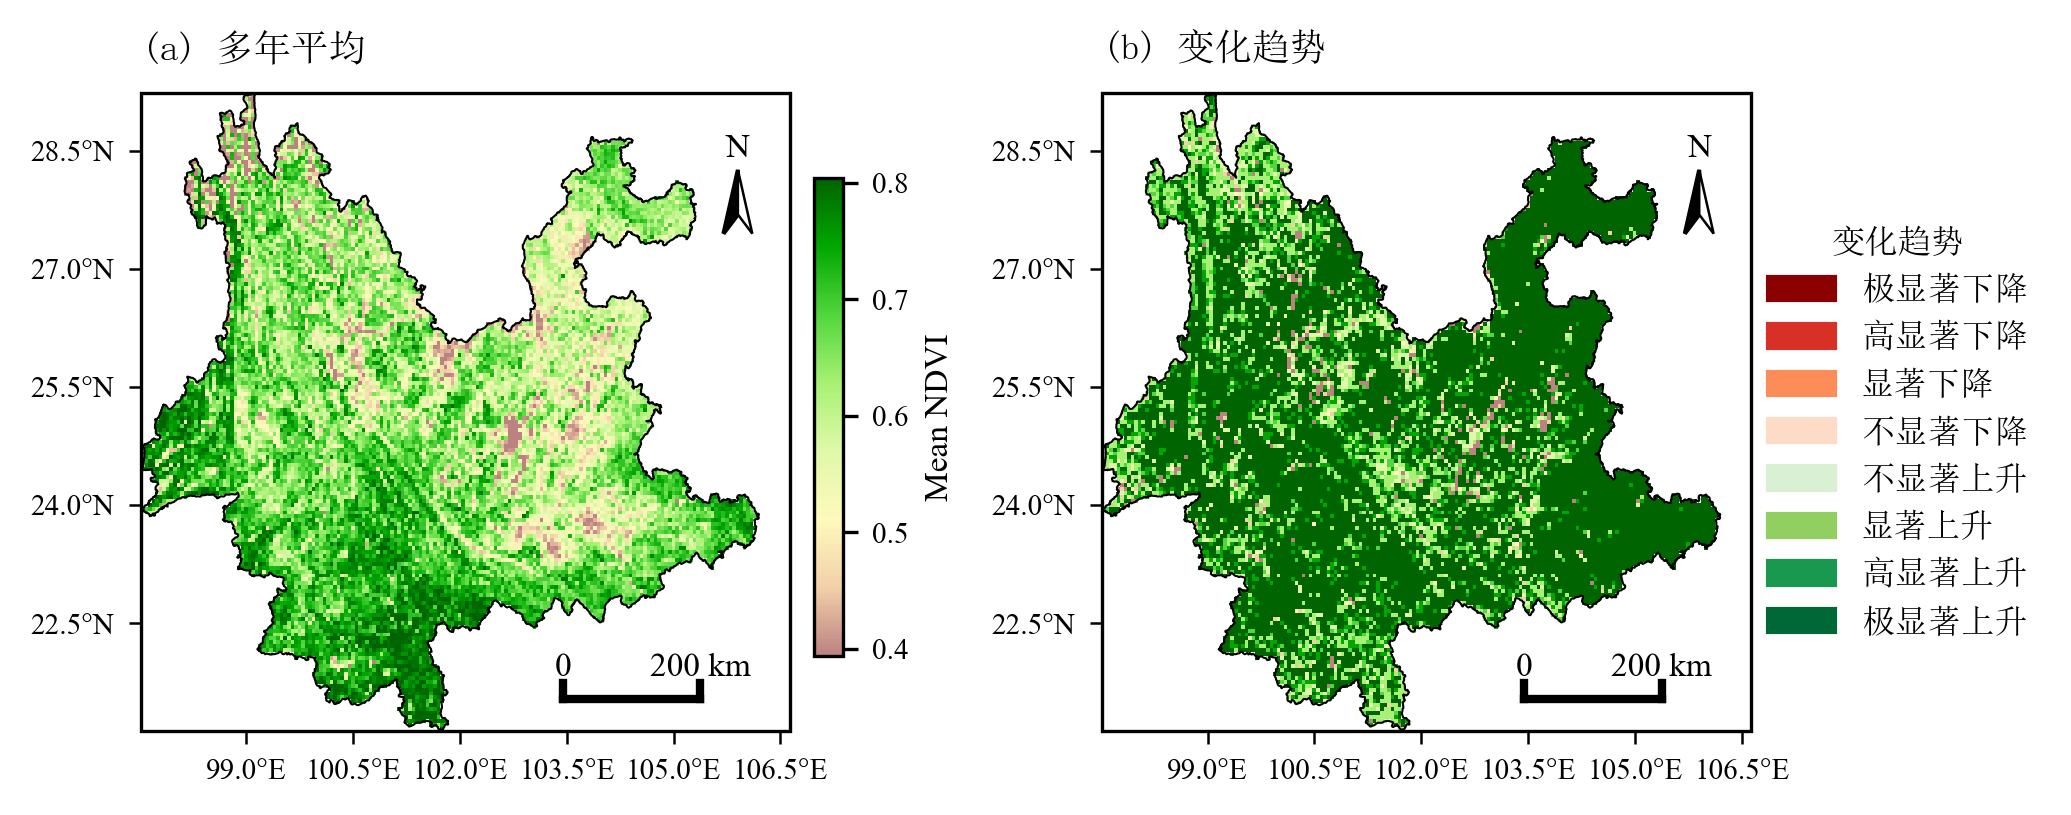


--- 8等级趋势统计结果 ---
极显著下降: 259 像元, 1.89%
高显著下降: 94 像元, 0.69%
显著下降: 67 像元, 0.49%
不显著下降: 620 像元, 4.52%
不显著上升: 1656 像元, 12.07%
显著上升: 520 像元, 3.79%
高显著上升: 1081 像元, 7.88%
极显著上升: 9419 像元, 68.67%

--- 多年平均 NDVI 有效像元占比 ---
<0.5: 1291 像元, 9.41%
0.5-0.6: 2909 像元, 21.21%
0.6-0.7: 5092 像元, 37.12%
>=0.7: 4424 像元, 32.25%


In [112]:
from matplotlib.font_manager import FontProperties
trend_colors = ["#bc8181", "#f3d0a9", "#fef9bc", "#e0f8a9", "#a7f174", "#52d63d", "#01a701", "#006400"]
cmap_trend = ListedColormap(trend_colors)

s = trend_ds["slope"]
p = trend_ds["p_value"]
mean  = trend_ds["mean"]
tc = xr.full_like(s, np.nan)

tc = xr.where((s < 0) & (p < 0.01), 1, tc)
tc = xr.where((s < 0) & (p >= 0.01) & (p < 0.05), 2, tc)
tc = xr.where((s < 0) & (p >= 0.05) & (p < 0.10), 3, tc)
tc = xr.where((s < 0) & (p >= 0.10), 4, tc)
tc = xr.where((s > 0) & (p >= 0.10), 5, tc)
tc = xr.where((s > 0) & (p >= 0.05) & (p < 0.10), 6, tc)
tc = xr.where((s > 0) & (p >= 0.01) & (p < 0.05), 7, tc)
tc = xr.where((s > 0) & (p < 0.01), 8, tc)

trend_ds["trend_class"] = tc
labels_cn = [
    '极显著下降',
    '高显著下降',
    '显著下降',
    '不显著下降',
    '不显著上升',
    '显著上升',
    '高显著上升',
    '极显著上升',
]

labels_en = [
    'Extremely significant decrease',
    'Highly significant decrease',
    'Significant decrease',
    'Non-significant decrease',
    'Non-significant increase',
    'Significant increase',
    'Highly significant increase',
    'Extremely significant increase'
]

labels_bi = [f'{cn} ({en})' for cn, en in zip(labels_cn, labels_en)]
patches = [mpatches.Patch(color=trend_8_colors[i], label=labels_cn [i]) for i in range(8)]
font_cn = FontProperties(family='SimSun', size=8)
font_cn_title = FontProperties(family='SimSun', size=9)

fig = plt.figure(figsize=(8, 2.5), dpi=300)

gs = fig.add_gridspec(
    1, 2,
    left=0.06, right=0.80,
    bottom=0.10, top=0.95,
    wspace=0.18
)


ax1 = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())
ax2 = fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree())
im1 = mean.plot(
    ax=ax1,
    transform=ccrs.PlateCarree(),
    cmap=custom_veg_cmap,
    robust=True,
    add_colorbar=False,
    add_labels=False
)

im2 =tc.plot(
    ax=ax2,
    transform=ccrs.PlateCarree(),
    cmap=cmap_trend_8,
    add_colorbar=False,
    vmin=0.5,
    vmax=8.5,
    add_labels=False
)

ax1.set_title("(a) 多年平均", loc='left', fontproperties=font_cn_title, pad=8)
ax2.set_title("(b) 变化趋势", loc='left', fontproperties=font_cn_title, pad=8)

xticks = [99, 100.5, 102, 103.5, 105, 106.5]
yticks = [22.5, 24, 25.5, 27, 28.5]

for ax in [ax1, ax2]:
    gdf.plot(ax=ax, edgecolor='black', facecolor='none', linewidth=0.5, zorder=5)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.3)
    add_north_arrow(ax, location=(0.92, 0.88), size=0.1)
    add_scalebar(ax, length_km=200, location=(0.65, 0.05))

    # 手动设置刻度位置
    ax.set_xticks(xticks, crs=ccrs.PlateCarree())
    ax.set_yticks(yticks, crs=ccrs.PlateCarree())

    # 经纬度格式
    ax.xaxis.set_major_formatter(LongitudeFormatter(number_format='.1f', degree_symbol='°'))
    ax.yaxis.set_major_formatter(LatitudeFormatter(number_format='.1f', degree_symbol='°'))

    # 刻度样式
    ax.tick_params(axis='both', which='major',
                   labelsize=7, direction='out',
                   length=3, width=0.6,
                   top=False, right=False)

# ==========================================
# 子图1：把色标放到右侧
# ==========================================
pos1 = ax1.get_position()

# 在 ax1 右边单独加一个竖直色标轴
cax1 = fig.add_axes([
    pos1.x1 + 0.01,     # x：紧贴 ax1 右侧
    pos1.y0 + 0.10,     # y
    0.012,              # width
    pos1.height * 0.75  # height
])

cbar1 = fig.colorbar(im1, cax=cax1, orientation='vertical')
cbar1.set_label('Mean NDVI', fontsize=8)
cbar1.ax.tick_params(labelsize=7)

legend = fig.legend(
    handles=patches,
    loc='center left',
    bbox_to_anchor=(0.76, 0.5),
    frameon=False,
    prop=font_cn,
    title="变化趋势"
)

legend.get_title().set_fontproperties(font_cn)
plt.show()

# ==========================================
# 6. 统计各等级面积占比
# ==========================================

total_count = trend_ds["trend_class"].count().values
print("\n--- 8等级趋势统计结果 ---")
for i in range(1, 9):
    class_count = (trend_ds["trend_class"] == i).sum().values
    print(f"{labels_cn[i-1]}: {class_count} 像元, {class_count / total_count * 100:.2f}%")

# ---- 多年平均 NDVI 分级面积占比 ----
arr = trend_ds["mean"].values
valid = np.isfinite(arr)
total_valid = valid.sum()

stats = {
    "<0.5":    ((arr < 0.5) & valid).sum(),
    "0.5-0.6": ((arr >= 0.5) & (arr < 0.6) & valid).sum(),
    "0.6-0.7": ((arr >= 0.6) & (arr < 0.7) & valid).sum(),
    ">=0.7":   ((arr >= 0.7) & valid).sum(),
}

print("\n--- 多年平均 NDVI 有效像元占比 ---")
for label, count in stats.items():
    print(f"{label}: {count} 像元, {count / total_valid * 100:.2f}%")

CV自然断点(截尾后): [0.02218260368760174, 0.04217303670815513, 0.05869193415837257, 0.07835270207068266, 0.10889891008327743, 0.14417245324579409]


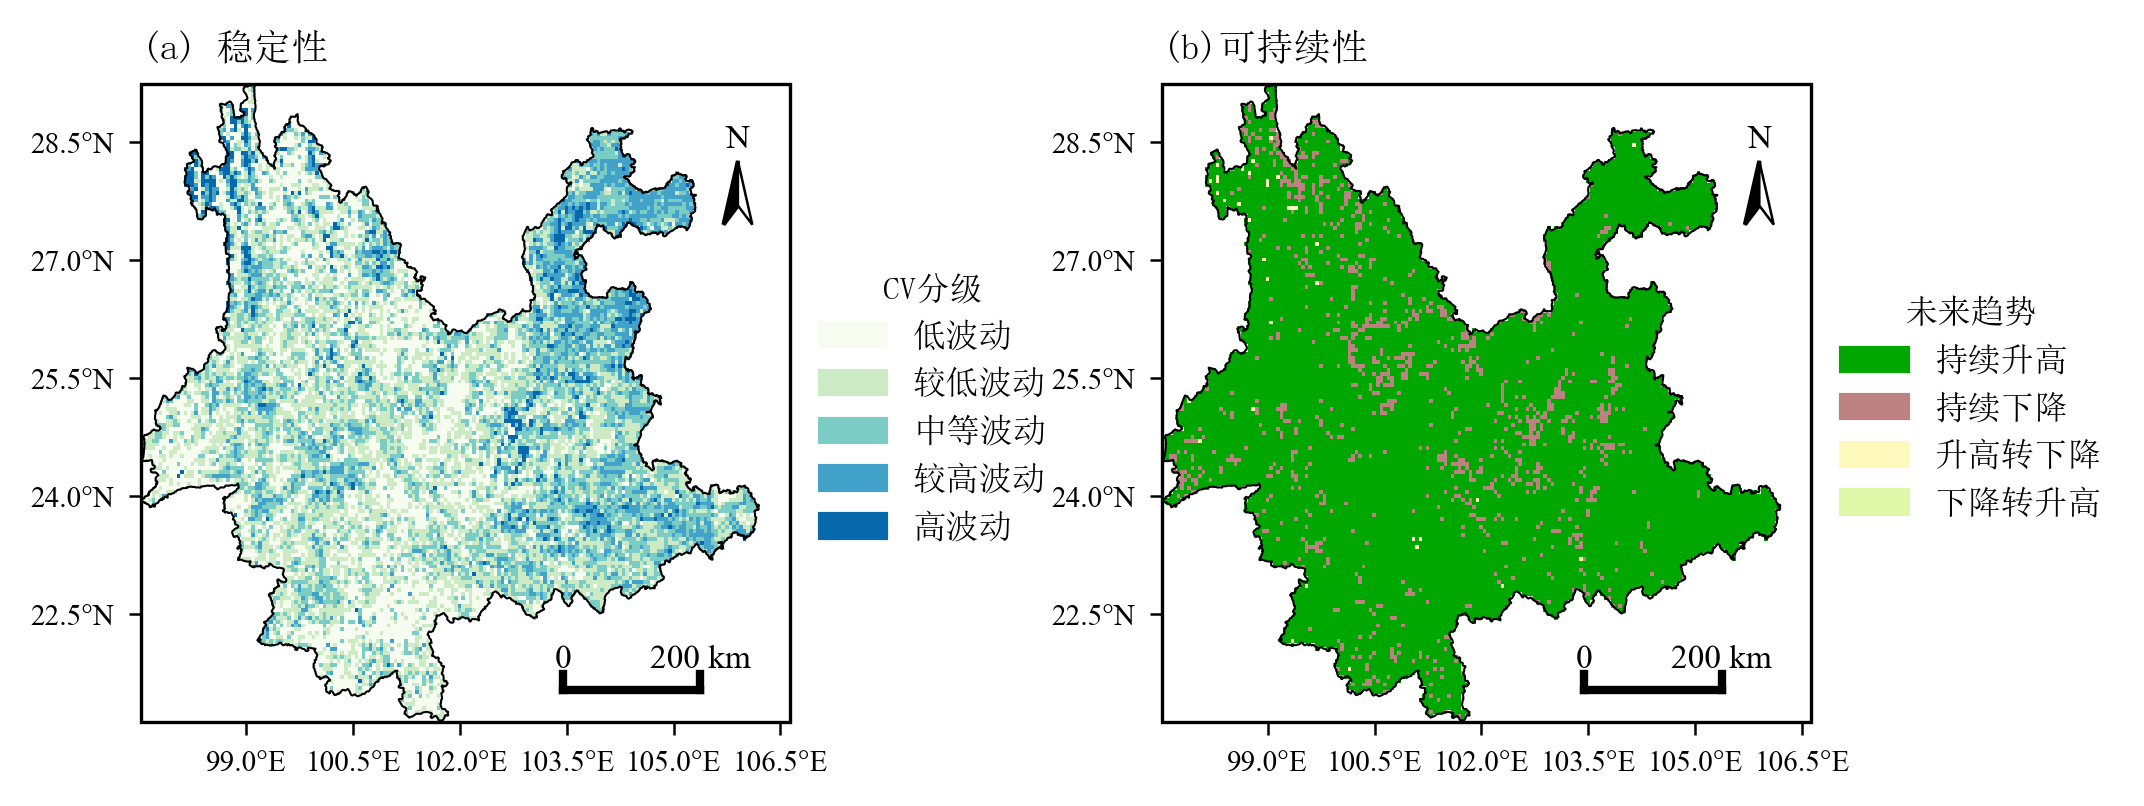

In [99]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.font_manager import FontProperties
from matplotlib.ticker import FuncFormatter
import numpy as np
import xarray as xr
import jenkspy

cv_values = trend_ds['cv'].values
cv_flat = cv_values[~np.isnan(cv_values)]

p1, p99 = np.nanpercentile(cv_flat, [1, 99])
cv_clip = np.clip(cv_values, p1, p99)
cv_flat_clip = cv_clip[~np.isnan(cv_clip)]

breaks_cv = jenkspy.jenks_breaks(cv_flat_clip, n_classes=5)
print("CV自然断点(截尾后):", breaks_cv)

cv_class_array = np.full_like(cv_values, np.nan)
for i in range(len(breaks_cv) - 1):
    if i == 0:
        mask = (cv_clip >= breaks_cv[i]) & (cv_clip <= breaks_cv[i+1])
    else:
        mask = (cv_clip > breaks_cv[i]) & (cv_clip <= breaks_cv[i+1])
    cv_class_array[mask] = i + 1

trend_ds['cv_class'] = (('lat', 'lon'), cv_class_array)


s = trend_ds['slope']
h = trend_ds['hurst']
hs_class = xr.full_like(s, np.nan)
# 1: 持续升高 (Slope > 0, Hurst > 0.5)
# 2: 持续下降 (Slope < 0, Hurst > 0.5)
# 3: 升高转下降 (Slope > 0, Hurst < 0.5)
# 4: 下降转升高 (Slope < 0, Hurst < 0.5)

hs_class = xr.where((s > 0) & (h > 0.5), 1, hs_class)
hs_class = xr.where((s < 0) & (h > 0.5), 2, hs_class)
hs_class = xr.where((s > 0) & (h < 0.5), 3, hs_class)
hs_class = xr.where((s < 0) & (h < 0.5), 4, hs_class)
trend_ds['hurst_slope_class'] = hs_class
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.font_manager import FontProperties
from matplotlib.ticker import FuncFormatter

import cartopy.crs as ccrs
import cartopy.feature as cfeature

# =========================
# 1. 字体设置
# =========================
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "SimSun"],
    "mathtext.fontset": "stix",
    "axes.unicode_minus": False,
    "font.size": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 8,
    "axes.titlesize": 9,
    "axes.linewidth": 0.8,
    "xtick.direction": "out",
    "ytick.direction": "out"
})

font_cn = FontProperties(family="SimSun", size=8)
font_cn_title = FontProperties(family="SimSun", size=9)

# =========================
# 2. 配色与标签
# =========================
# CV 5级颜色
cv_colors = ['#f7fcf0', '#ccebc5', '#7bccc4', '#43a2ca', '#0868ac']
cmap_cv = ListedColormap(cv_colors)
norm_cv = BoundaryNorm([0.5, 1.5, 2.5, 3.5, 4.5, 5.5], cmap_cv.N)

labels_cv = [
    '低波动',
    '较低波动',
    '中等波动',
    '较高波动',
    '高波动'
]

# Hurst-Slope 4级颜色

veg_colors = [
    "#bc8181", # 红褐 (低值，如裸地)
    "#f3d0a9", # 沙黄
    "#fef9bc", # 浅黄
    "#e0f8a9", # 嫩绿
    "#a7f174", # 浅翠绿
    "#52d63d", # 绿
    "#01a701", # 深绿
    "#006400"  # 墨绿 (高值，如森林)
]


hs_colors = ['#01a701', '#bc8181', '#fef9bc', '#e0f8a9']
cmap_hs = ListedColormap(hs_colors)
norm_hs = BoundaryNorm([0.5, 1.5, 2.5, 3.5, 4.5], cmap_hs.N)

labels_hs = [
    '持续升高',
    '持续下降',
    '升高转下降',
    '下降转升高'
]

xmin, ymin, xmax, ymax = gdf.total_bounds
extent = [xmin, xmax, ymin, ymax]

xticks = np.linspace(xmin, xmax, 4)
yticks = np.linspace(ymin, ymax, 4)

def lon_fmt(x, pos=None):
    if float(x).is_integer():
        return f"{int(x)}°E"
    return f"{x:.1f}°E"

def lat_fmt(y, pos=None):
    if float(y).is_integer():
        return f"{int(y)}°N"
    return f"{y:.1f}°N"

# =========================
# 4. 绘图
# =========================
fig = plt.figure(figsize=(8.5,2.5), dpi=300)
gs = fig.add_gridspec(
    1, 2,
    left=0.06, right=0.80,
    bottom=0.10, top=0.95,
    wspace=0.18
)

ax1 = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())
ax2 = fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree())

# -------------------------
# 子图1：CV自然断点5分级
# -------------------------
im1 = trend_ds["cv_class"].plot(
    ax=ax1,
    transform=ccrs.PlateCarree(),
    cmap=cmap_cv,
    norm=norm_cv,
    add_colorbar=False,
    add_labels=False
)
ax1.set_title("(a) 稳定性", loc="left", fontproperties=font_cn_title, pad=6)


im2 = trend_ds["hurst_slope_class"].plot(
    ax=ax2,
    transform=ccrs.PlateCarree(),
    cmap=cmap_hs,
    norm=norm_hs,
    add_colorbar=False,
    add_labels=False
)
ax2.set_title("(b)可持续性", loc="left", fontproperties=font_cn_title, pad=6)

xticks = [99, 100.5, 102, 103.5, 105, 106.5]
yticks = [22.5, 24, 25.5, 27, 28.5]

for ax in [ax1, ax2]:
    gdf.plot(ax=ax, edgecolor='black', facecolor='none', linewidth=0.5, zorder=5)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.3)
    add_north_arrow(ax, location=(0.92, 0.88), size=0.1)
    add_scalebar(ax, length_km=200, location=(0.65, 0.05))

    # 手动设置刻度位置
    ax.set_xticks(xticks, crs=ccrs.PlateCarree())
    ax.set_yticks(yticks, crs=ccrs.PlateCarree())

    # 经纬度格式
    ax.xaxis.set_major_formatter(LongitudeFormatter(number_format='.1f', degree_symbol='°'))
    ax.yaxis.set_major_formatter(LatitudeFormatter(number_format='.1f', degree_symbol='°'))

    # 刻度样式
    ax.tick_params(axis='both', which='major',
                   labelsize=7, direction='out',
                   length=3, width=0.6,
                   top=False, right=False)

# =========================
# 5. 图例
# =========================
patches_cv = [mpatches.Patch(color=cv_colors[i], label=labels_cv[i]) for i in range(5)]
patches_hs = [mpatches.Patch(color=hs_colors[i], label=labels_hs[i]) for i in range(4)]

# 左图图例
pos1 = ax1.get_position()
legend1 = fig.legend(
    handles=patches_cv,
    loc='center left',
    bbox_to_anchor=(pos1.x1, 0.52),
    frameon=False,
    prop=font_cn,
    title="CV分级"
)
legend1.get_title().set_fontproperties(font_cn)

# 右图图例
pos2 = ax2.get_position()
legend2 = fig.legend(
    handles=patches_hs,
    loc='center left',
    bbox_to_anchor=(pos2.x1 , 0.52),
    frameon=False,
    prop=font_cn,
    title="未来趋势"
)
legend2.get_title().set_fontproperties(font_cn)

plt.show()


In [92]:
print("CV最小值:", np.nanmin(cv_values))
print("CV最大值:", np.nanmax(cv_values))
print("CV均值:", np.nanmean(cv_values))
print("CV分位数:", np.nanpercentile(cv_flat, [1, 5, 25, 50, 75, 95, 99]))

CV最小值: -3.1334323537686917
CV最大值: 15.231205820603446
CV均值: 0.059884933078684935
CV分位数: [0.0221826  0.02872868 0.04159437 0.05400519 0.06964258 0.10169364
 0.14417245]


In [133]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches
from matplotlib.font_manager import FontProperties
from matplotlib.ticker import FuncFormatter
from scipy.stats import linregress, t as student_t
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap, BoundaryNorm

# =========================
# 0. 全局字体与样式
# =========================
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "SimSun"],
    "mathtext.fontset": "stix",
    "axes.unicode_minus": False,
    "font.size": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "axes.titlesize": 10,
    "axes.linewidth": 0.8,
    "xtick.direction": "out",
    "ytick.direction": "out"
})

font_cn = FontProperties(family="SimSun", size=8)
font_cn_title = FontProperties(family="SimSun", size=10)

# =========================
# 1. 数据预处理与季节计算
# =========================
def get_seasonal_data(ds):
    var_name = list(ds.data_vars)[0]
    da = ds[var_name]

    seasons = {
        "春季": [3, 4, 5],
        "夏季": [6, 7, 8],
        "秋季": [9, 10, 11],
        "冬季": [12, 1, 2]
    }

    results = {}
    for name, months in seasons.items():
        sel = da.sel(time=da.time.dt.month.isin(months))

        # 冬季跨年：12月归下一年
        season_year = xr.where(
            sel["time"].dt.month == 12,
            sel["time"].dt.year + 1,
            sel["time"].dt.year
        )
        sel = sel.assign_coords(season_year=("time", season_year.data))

        # 逐季逐年平均
        annual = sel.groupby("season_year").mean("time", skipna=True)

        # 仅保留完整季节（至少3个月）
        count = xr.DataArray(
            np.ones(sel.sizes["time"]),
            coords={"time": sel.time},
            dims=["time"]
        ).assign_coords(season_year=("time", season_year.data))

        count_by_year = count.groupby("season_year").sum()
        valid_years = count_by_year.where(count_by_year >= 3, drop=True).season_year.values
        annual = annual.sel(season_year=valid_years)

        results[name] = annual

    return results

# =========================
# 2. 逐像元计算 slope、p_value、trend_class
# =========================
def calc_slope_p_class(data):
    """
    data: xarray.DataArray, dims = (season_year, lat, lon) or (season_year, y, x)
    返回:
        slope_da, p_da, class_da
    class:
        1 极显著下降
        2 高显著下降
        3 显著下降
        4 不显著下降
        5 不显著上升
        6 显著上升
        7 高显著上升
        8 极显著上升
    """
    time_dim = "season_year"
    spatial_dims = [d for d in data.dims if d != time_dim]

    arr = data.values
    ntime = arr.shape[0]
    shp = arr.shape[1:]

    x = data[time_dim].values.astype(float)
    slope = np.full(shp, np.nan, dtype=float)
    pval = np.full(shp, np.nan, dtype=float)
    tclass = np.full(shp, np.nan, dtype=float)

    # 展平空间维
    arr2 = arr.reshape(ntime, -1)

    for k in range(arr2.shape[1]):
        y = arr2[:, k]
        mask = np.isfinite(y)
        if mask.sum() < 3:
            continue

        xx = x[mask]
        yy = y[mask]

        # 线性回归
        res = linregress(xx, yy) 
        slope_val = res.slope
        p_val = res.pvalue

        slope.flat[k] = slope_val
        pval.flat[k] = p_val

        # 8级分类
        if slope_val < 0:
            if p_val < 0.001:
                tclass.flat[k] = 1
            elif p_val < 0.01:
                tclass.flat[k] = 2
            elif p_val < 0.05:
                tclass.flat[k] = 3
            else:
                tclass.flat[k] = 4
        elif slope_val > 0:
            if p_val >= 0.05:
                tclass.flat[k] = 5
            elif p_val < 0.05 and p_val >= 0.01:
                tclass.flat[k] = 6
            elif p_val < 0.01 and p_val >= 0.001:
                tclass.flat[k] = 7
            elif p_val < 0.001:
                tclass.flat[k] = 8

    coords = {d: data.coords[d] for d in spatial_dims}
    slope_da = xr.DataArray(slope, coords=coords, dims=spatial_dims)
    p_da = xr.DataArray(pval, coords=coords, dims=spatial_dims)
    class_da = xr.DataArray(tclass, coords=coords, dims=spatial_dims)
    return slope_da, p_da, class_da

# =========================
# 3. 指标计算
# =========================
def calculate_metrics(seasonal_dict):
    metrics = {
        "ts": {},
        "clim": {},
        "slope": {},
        "p": {},
        "trend_class": {}
    }
    sample = seasonal_dict["春季"]
    spatial_dims = [d for d in sample.dims if d != "season_year"]

    for name, data in seasonal_dict.items():
        # 第1列：区域平均历年变化
        metrics["ts"][name] = data.mean(dim=spatial_dims, skipna=True)

        # 第2列：多年均值空间分布
        metrics["clim"][name] = data.mean(dim="season_year", skipna=True)

        # 第3列：趋势+显著性8级分类
        slope_da, p_da, class_da = calc_slope_p_class(data)
        metrics["slope"][name] = slope_da
        metrics["p"][name] = p_da
        metrics["trend_class"][name] = class_da

    return metrics

# =========================
# 4. 经纬度格式器
# =========================
def lon_fmt(x, pos=None):
    if float(x).is_integer():
        return f"{int(x)}°E"
    return f"{x:.1f}°E"

def lat_fmt(y, pos=None):
    if float(y).is_integer():
        return f"{int(y)}°N"
    return f"{y:.1f}°N"

# =========================
# 5. 地图样式
# =========================
def setup_map(ax, gdf):
    ax.add_feature(cfeature.COASTLINE, linewidth=0.4, zorder=10)
    gdf.plot(ax=ax, edgecolor="black", facecolor="none", linewidth=0.6, zorder=12)

    xmin, ymin, xmax, ymax = gdf.total_bounds
    ax.set_extent([xmin, xmax, ymin, ymax], crs=ccrs.PlateCarree())

    xticks = np.linspace(xmin, xmax, 4)
    yticks = np.linspace(ymin, ymax, 4)

    ax.set_xticks(xticks, crs=ccrs.PlateCarree())
    ax.set_yticks(yticks, crs=ccrs.PlateCarree())
    ax.xaxis.set_major_formatter(FuncFormatter(lon_fmt))
    ax.yaxis.set_major_formatter(FuncFormatter(lat_fmt))
    ax.tick_params(
        axis='both', which='major',
        labelsize=7, direction='out',
        length=3, width=0.6,
        top=False, right=False
    )
    add_north_arrow(ax, location=(0.95, 0.90), size=0.1)
    add_scalebar(ax, length_km=200, location=(0.65, 0.05))
    
seasonal_data = get_seasonal_data(clipped_ds)
m = calculate_metrics(seasonal_data)
season_list = ["春季", "夏季", "秋季", "冬季"]

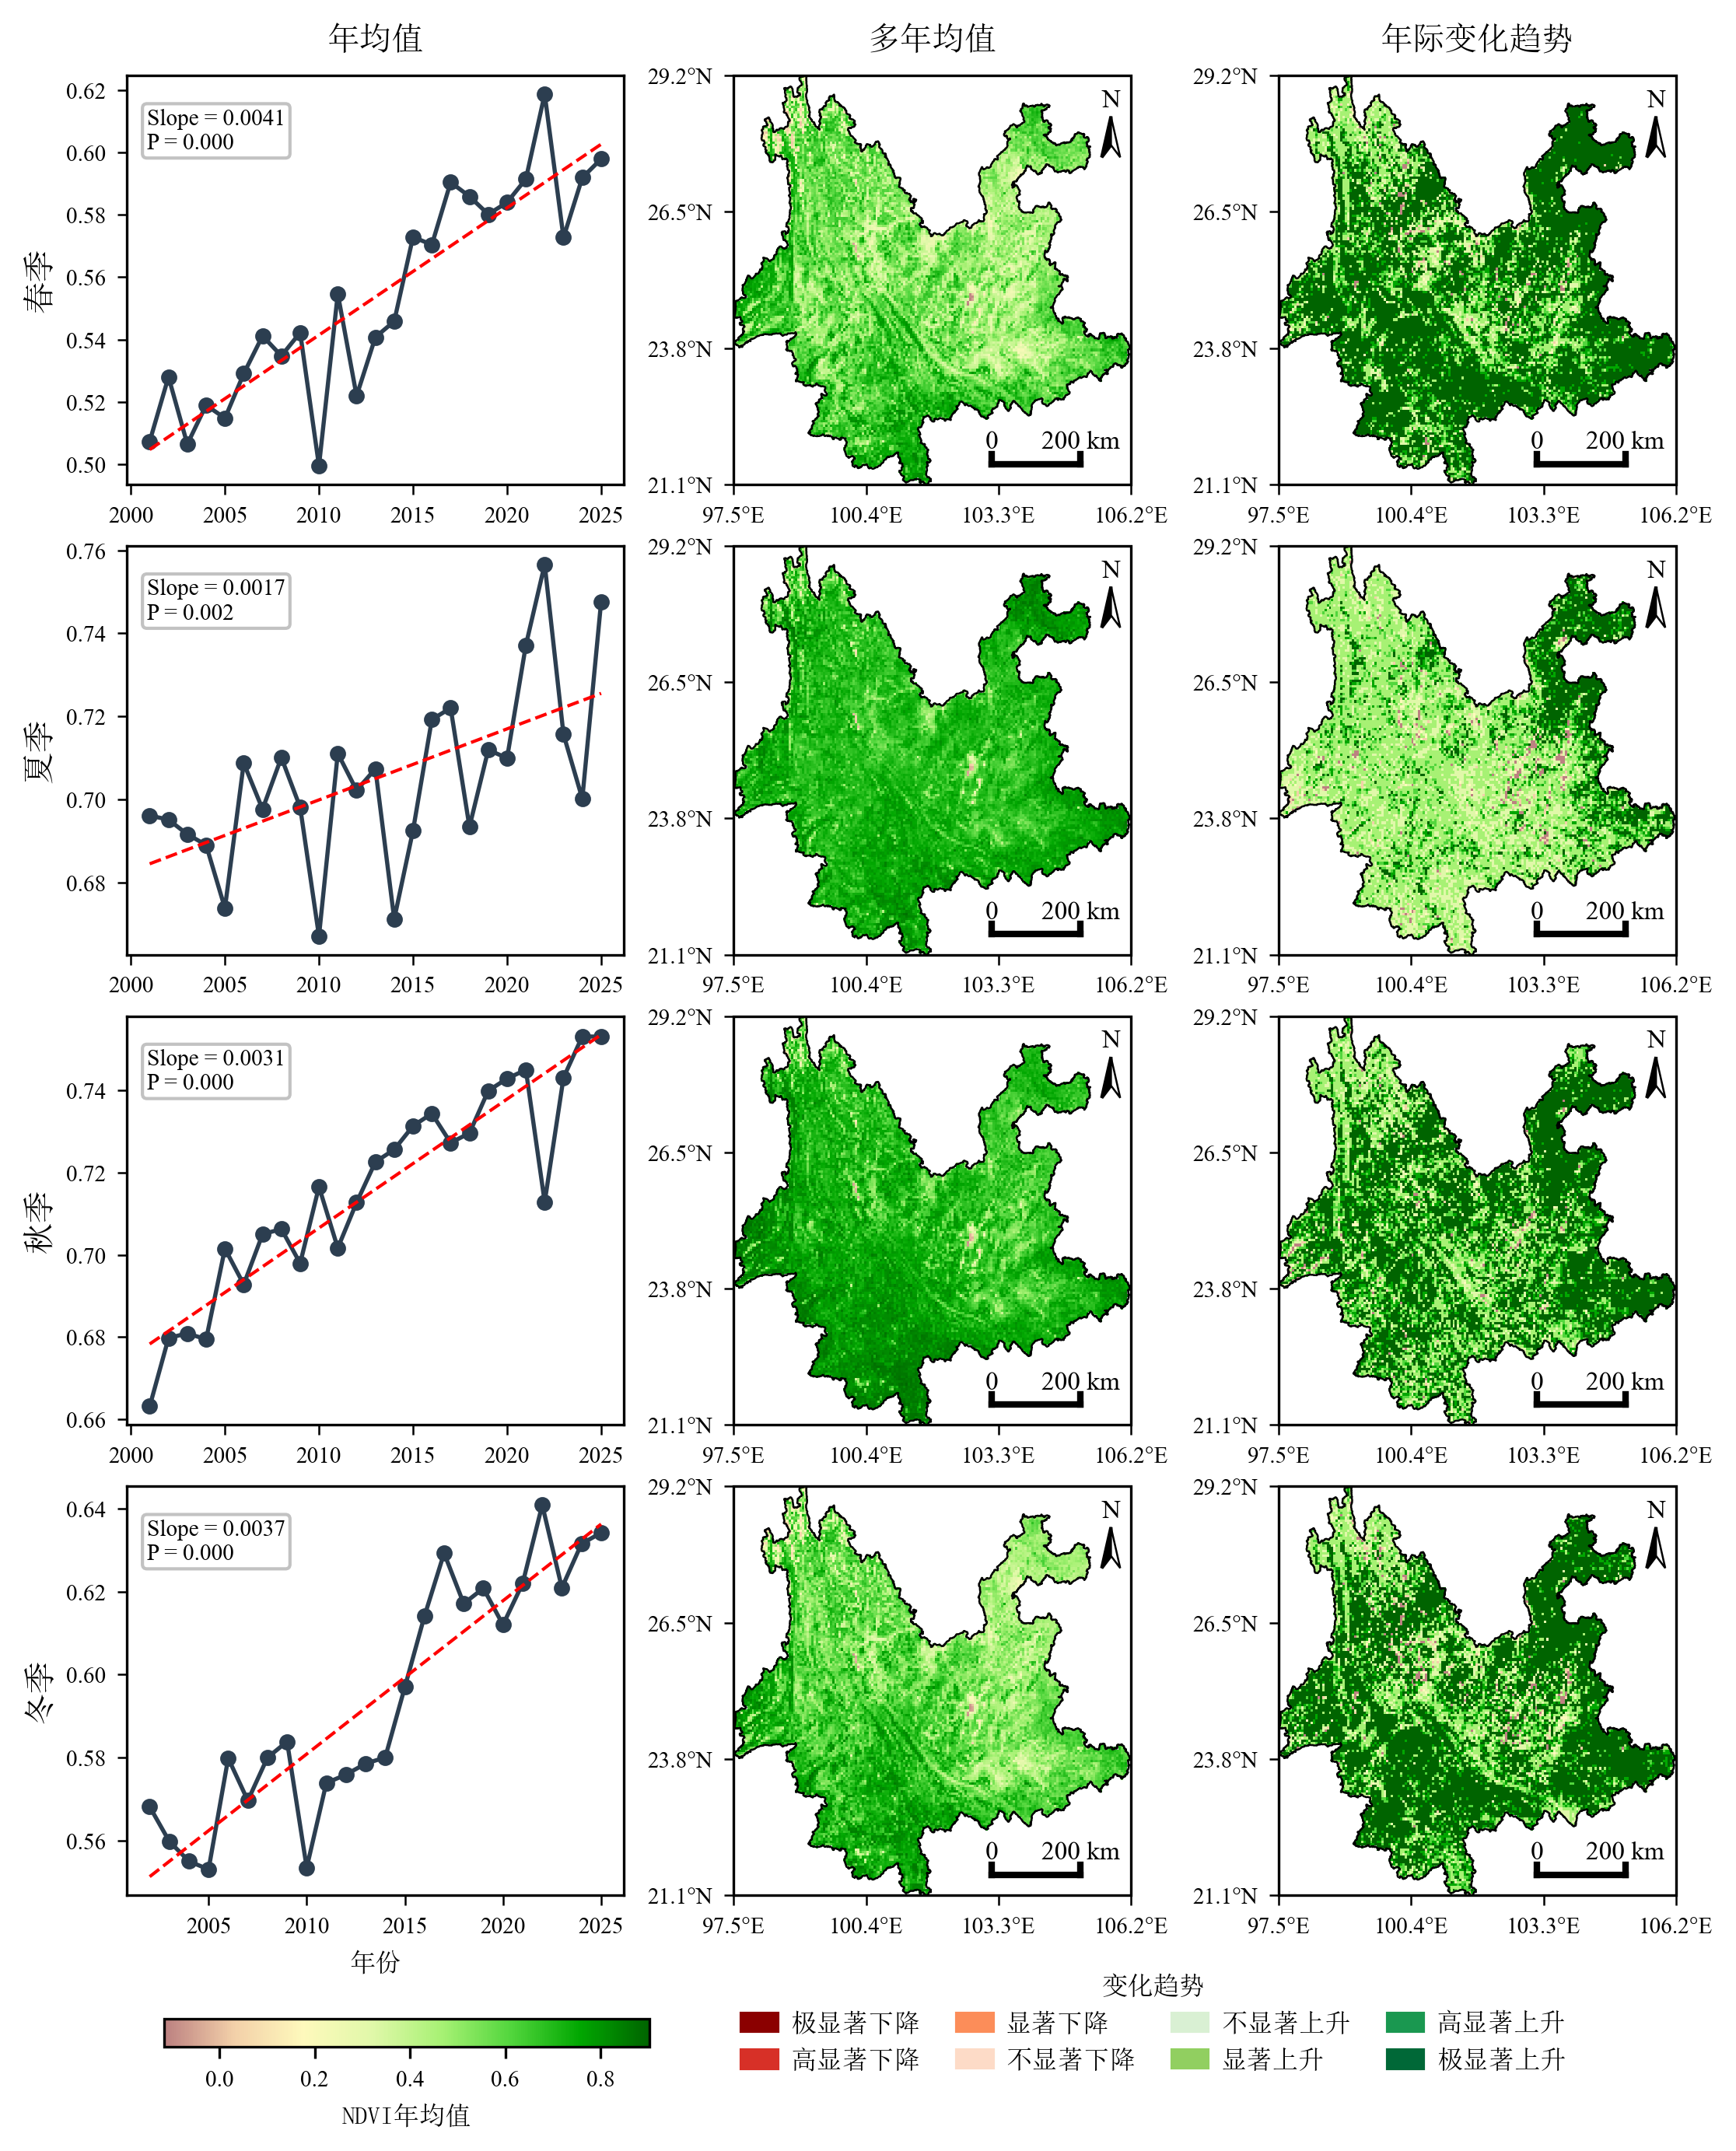

In [134]:
# 第2列统一色标
clim_vmin = min(float(m["clim"][s].min(skipna=True)) for s in season_list)
clim_vmax = max(float(m["clim"][s].max(skipna=True)) for s in season_list)
clim_norm = mpl.colors.Normalize(vmin=clim_vmin, vmax=clim_vmax)
fig = plt.figure(figsize=(8, 10), dpi=300)
gs = fig.add_gridspec(
    4, 3,
    width_ratios=[1.05, 1.0, 1.0],
    left=0.10, right=0.95,
    bottom=0.16, top=0.94,
    hspace=0.15, wspace=0.15
)

col_titles = ["年均值", "多年均值", "年际变化趋势"]

axes_ts, axes_clim, axes_trend = [], [], []

for r, name in enumerate(season_list):
    ax1 = fig.add_subplot(gs[r, 0])
    axes_ts.append(ax1)

    ts = m["ts"][name]
    x = ts.season_year.values
    y = ts.values
    mask = np.isfinite(y)

    ax1.plot(x[mask], y[mask], 'o-', ms=4, lw=1.3, color='#2c3e50')

    if mask.sum() >= 2:
        res = linregress(x[mask], y[mask])
        yfit = res.intercept + res.slope * x[mask]
        ax1.plot(x[mask], yfit, '--', lw=1, color='red')
        ax1.text(
            0.04, 0.92,
            f"Slope = {res.slope:.4f}\nP = {res.pvalue:.3f}",
            transform=ax1.transAxes,
            fontsize=7,
            ha='left', va='top',
            bbox=dict(fc='white', ec='0.7', alpha=0.8, boxstyle='round,pad=0.2')
        )

    if r == 0:
        ax1.set_title(col_titles[0], fontproperties=font_cn_title, pad=8)
    ax1.set_ylabel(name, fontproperties=font_cn_title)
    if r == 3:
        ax1.set_xlabel("年份", fontproperties=font_cn)
    else:
        ax1.set_xlabel("")
    ax1.tick_params(labelsize=7, direction='out', length=3, width=0.6)

    ax2 = fig.add_subplot(gs[r, 1], projection=ccrs.PlateCarree())
    axes_clim.append(ax2)

    im2 = m["clim"][name].plot(
        ax=ax2,
        transform=ccrs.PlateCarree(),
        cmap=ndvi_map,
        norm=clim_norm,
        add_colorbar=False,
        add_labels=False
    )
    setup_map(ax2, gdf)
    if r == 0:
        ax2.set_title(col_titles[1], fontproperties=font_cn_title, pad=8)


    ax3 = fig.add_subplot(gs[r, 2], projection=ccrs.PlateCarree())
    axes_trend.append(ax3)

    im3 = m["trend_class"][name].plot(
        ax=ax3,
        transform=ccrs.PlateCarree(),
        cmap=cmap_trend,

        add_colorbar=False,
        add_labels=False
    )
    setup_map(ax3, gdf)
    if r == 0:
        ax3.set_title(col_titles[2], fontproperties=font_cn_title, pad=8)

cbar_width = 0.26
cbar_height = 0.012
cbar_left = 0.25 - cbar_width / 2

cbar_ax2 = fig.add_axes([cbar_left, 0.095, cbar_width, cbar_height])
cbar2 = fig.colorbar(im2, cax=cbar_ax2, orientation='horizontal')
cbar2.set_label('NDVI年均值', fontproperties=font_cn)
cbar2.ax.tick_params(labelsize=7)

patches = [mpatches.Patch(color=trend_8_colors[i], label=labels_cn[i]) for i in range(8)]
legend = fig.legend(
    handles=patches,
    loc='lower center',
    bbox_to_anchor=(0.65, 0.08),   # 与色标同样以 0.5 为中心
    ncol=4,
    frameon=False,
    prop=font_cn,
    title="变化趋势",
    columnspacing=1.4,
    handlelength=1.4,
    handletextpad=0.5,
    borderaxespad=0.0
)
legend.get_title().set_fontproperties(font_cn)
plt.show()